In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [6]:
td_idx=all_bursts['group']=='TD'
asd_idx=all_bursts['group']=='ASD'
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'
hemi_idx = all_bursts['cluster']=='contra'

In [ ]:
waveform_times=all_bursts['waveform_times']

In [7]:
subject_ids=np.unique(all_bursts['subject_id'])
groups={}
for subject_id in subject_ids:
    group=all_bursts['group'][all_bursts['subject_id']==subject_id][0].strip()
    groups[subject_id]=group
n_td=len(np.unique(all_bursts['subject_id'][td_idx]))
n_asd=len(np.unique(all_bursts['subject_id'][asd_idx]))
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


min=0.887531412495456, max=0.9995637811951761


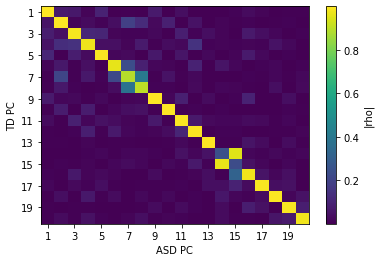

In [14]:
td_pca = PCA(n_components=20)
td_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & td_idx,:])
td_pca=td_pca.fit(td_burst_std)

asd_pca = PCA(n_components=20)
asd_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & asd_idx,:])
asd_pca=asd_pca.fit(asd_burst_std)

def spearman_correlation_matrix(pca1, pca2):
    eigenvectors1 = pca1.components_.T
    eigenvectors2 = pca2.components_.T
    n_components = eigenvectors1.shape[1]
    
    corr_matrix = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            corr, _ = spearmanr(eigenvectors1[:, i], eigenvectors2[:, j])
            corr_matrix[i, j] = abs(corr)  # Absolute value of the Spearman correlation
    return corr_matrix

pca_corr_matrix = spearman_correlation_matrix(td_pca, asd_pca)
max_corrs=[]
for i in range(pca_corr_matrix.shape[0]):
    max_corrs.append(np.max(pca_corr_matrix[i,:]))
print(f'min={np.min(max_corrs)}, max={np.max(max_corrs)}')

plt.figure()
ax=plt.subplot(1,1,1)
im=ax.imshow(pca_corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, label="|rho|")
ax.set_xlabel('ASD PC')
ax.set_ylabel('TD PC')
ax.set_xticks(np.arange(0,20,2))
ax.set_xticklabels(np.arange(0,20,2)+1)
ax.set_yticks(np.arange(0,20,2))
_=ax.set_yticklabels(np.arange(0,20,2)+1)

In [22]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
    waveforms_scaled = RobustScaler().fit_transform(waveforms)

    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


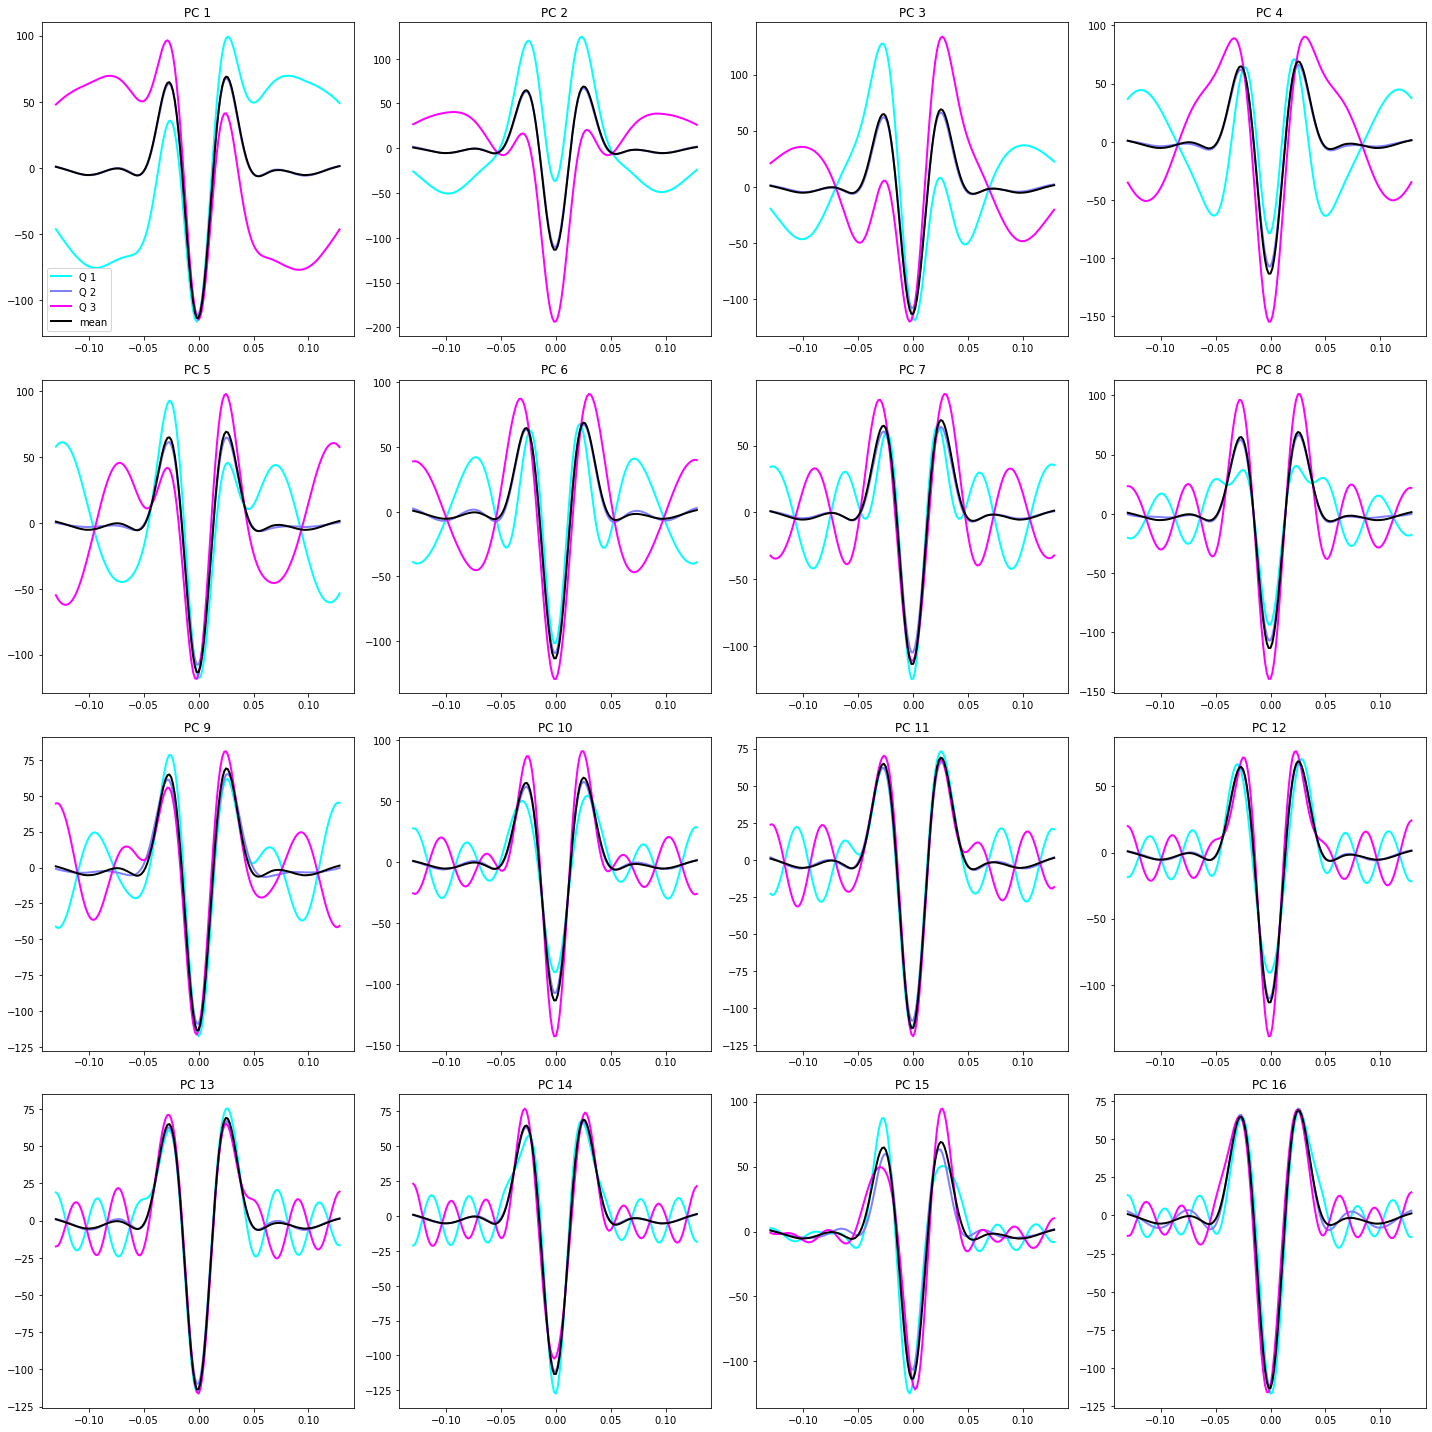

In [147]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [148]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={epoch_type: [] for epoch_type in epoch_types}
for subject_id in subject_ids:
    
    epoch_type='STIM'
    b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type)
    pc_score_ts=[]
    for t_idx in range(len(stim_time_bins)-1):
        st=stim_time_bins[t_idx]
        en=stim_time_bins[t_idx+1]
        bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
        ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
        pc_score_ts.append(ms)
    pc_score_ts=np.array(pc_score_ts)
    pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
    subject_score_ts[epoch_type].append(pc_score_ts)
    
    epoch_type='RESP'
    b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type)
    pc_score_ts=[]
    for t_idx in range(len(resp_time_bins)-1):
        st=resp_time_bins[t_idx]
        en=resp_time_bins[t_idx+1]
        bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
        ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
        pc_score_ts.append(ms)
    pc_score_ts=np.array(pc_score_ts)
    pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
    subject_score_ts[epoch_type].append(pc_score_ts)
for epoch_type in epoch_types:
    subject_score_ts[epoch_type]=np.array(subject_score_ts[epoch_type])

9.999000099990002e-05


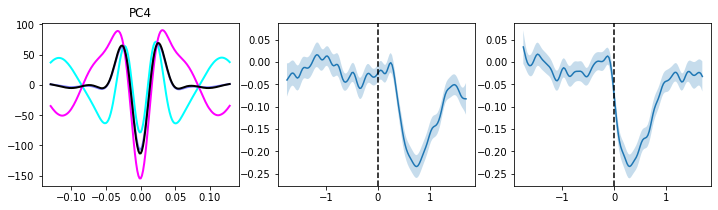

9.999000099990002e-05


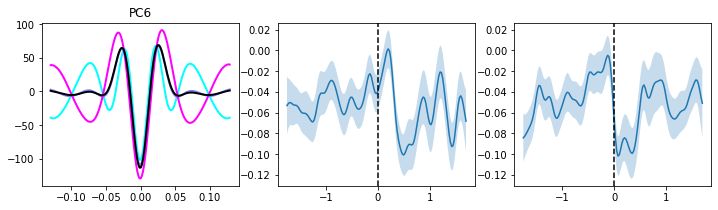

0.0005999400059994001


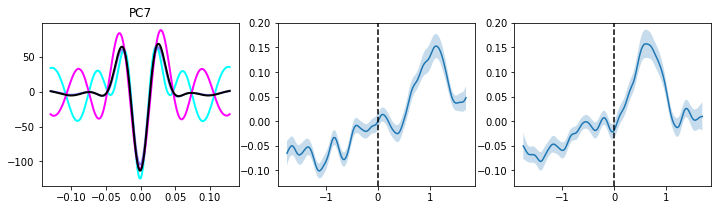

9.999000099990002e-05


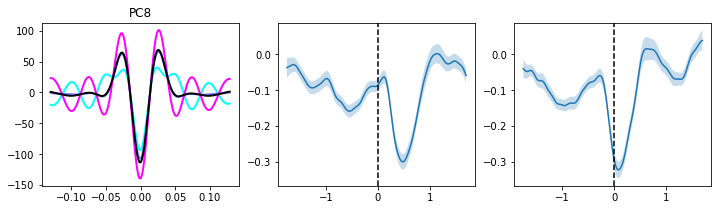

9.999000099990002e-05


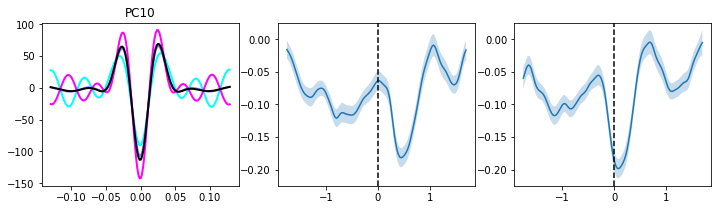

9.999000099990002e-05


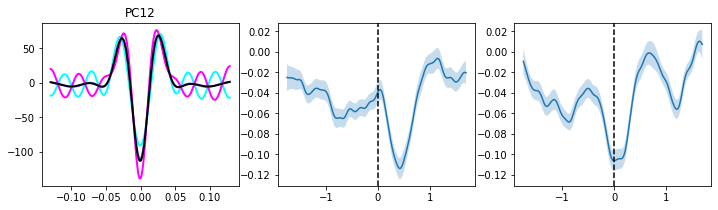

In [149]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -.5) & (stim_time_bins[:-1] < 0)
resp_mask = (resp_time_bins[:-1] > -.25) & (resp_time_bins[:-1] < .5)

task_pcs=[]

for pc in shuffling_results:
    m_stim = np.nanmean(subject_score_ts['STIM'], axis=0)[:, pc]
    se_stim = np.nanstd(subject_score_ts['STIM'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM'].shape[0])
    m_resp = np.nanmean(subject_score_ts['RESP'], axis=0)[:, pc]
    se_resp = np.nanstd(subject_score_ts['RESP'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data = subject_score_ts['STIM'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data = subject_score_ts['RESP'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline = np.nanvar(stim_data[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp = np.nanvar(resp_data[:, resp_mask], axis=1, ddof=1)

    diff = var_resp - var_baseline              # ?_i
    obs_stat = np.mean(diff)                    # observed mean difference across subjects

    # Sign-flip permutation for paired test
    null_stats = np.zeros(n_perm)
    for p in range(n_perm):
        signs = np.random.choice([1, -1], size=diff.shape[0])
        null_stats[p] = np.mean(diff * signs)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val = (np.sum(null_stats >= obs_stat) + 1) / (n_perm + 1)
    
    if p_val*len(shuffling_results)<0.05:
        print(p_val)
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim)
        ax1.fill_between(stim_time_bins[:-1], m_stim-se_stim, m_stim+se_stim, alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp)
        ax2.fill_between(resp_time_bins[:-1], m_resp-se_resp, m_resp+se_resp, alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

stat_fun(H1): min=-1.879128 max=6.939525
Running initial clustering …
Using 1388 thresholds from 0.00 to 6.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.409569 max=1.247638
Running initial clustering …
Using 1282 thresholds from 0.00 to 6.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.839731 max=6.558612
Running initial clustering …
Using 1312 thresholds from 0.00 to 6.55 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.778840 max=6.285969
Running initial clustering …
Using 1356 thresholds from 0.00 to 6.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.406563 max=5.528414
Running initial clustering …
Using 1282 thresholds from 0.00 to 6.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

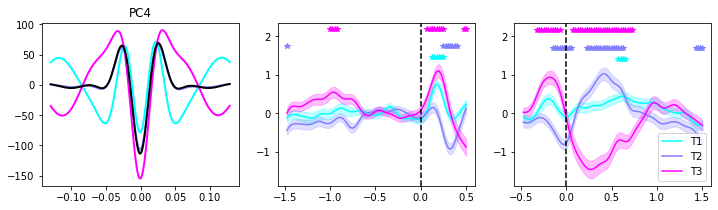

stat_fun(H1): min=-2.714391 max=3.154169
Running initial clustering …
Using 631 thresholds from 0.00 to 3.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.741973 max=2.103701
Running initial clustering …
Using 749 thresholds from 0.00 to 3.74 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.498163 max=6.540923
Running initial clustering …
Using 1309 thresholds from 0.00 to 6.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.224502 max=2.835878
Running initial clustering …
Using 1045 thresholds from 0.00 to 5.22 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.398565 max=4.053820
Running initial clustering …
Using 880 thresholds from 0.00 to 4.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

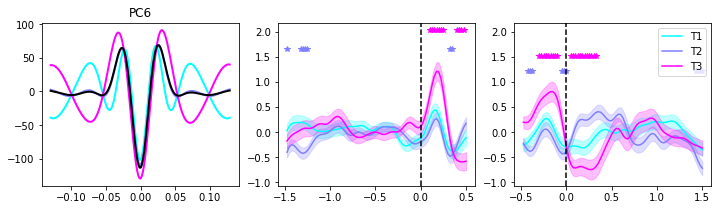

stat_fun(H1): min=-5.069654 max=4.177630
Running initial clustering …
Using 1014 thresholds from 0.00 to 5.07 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.415016 max=4.446541
Running initial clustering …
Using 890 thresholds from 0.00 to 4.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.471101 max=6.221988
Running initial clustering …
Using 1245 thresholds from 0.00 to 6.22 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.750575 max=3.324404
Running initial clustering …
Using 1151 thresholds from 0.00 to 5.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.993359 max=6.324712
Running initial clustering …
Using 1265 thresholds from 0.00 to 6.32 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

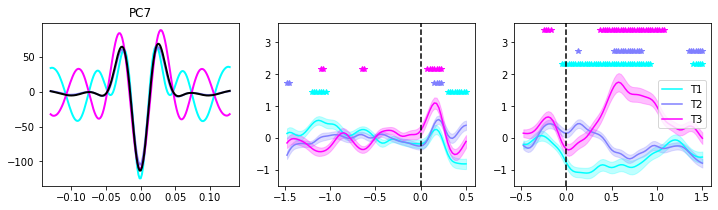

stat_fun(H1): min=-5.483181 max=5.419221
Running initial clustering …
Using 1097 thresholds from 0.00 to 5.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.512708 max=4.723315
Running initial clustering …
Using 945 thresholds from 0.00 to 4.72 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-9.606661 max=7.063376
Running initial clustering …
Using 1922 thresholds from 0.00 to 9.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.635624 max=4.706075
Running initial clustering …
Using 1328 thresholds from 0.00 to 6.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-9.905919 max=5.024364
Running initial clustering …
Using 1982 thresholds from 0.00 to 9.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

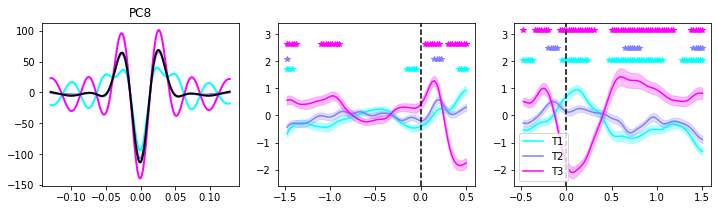

stat_fun(H1): min=-3.545095 max=2.657073
Running initial clustering …
Using 710 thresholds from 0.00 to 3.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.265225 max=3.927166
Running initial clustering …
Using 786 thresholds from 0.00 to 3.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.184079 max=6.130185
Running initial clustering …
Using 1437 thresholds from 0.00 to 7.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.778526 max=1.963028
Running initial clustering …
Using 1356 thresholds from 0.00 to 6.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.269161 max=5.805893
Running initial clustering …
Using 1654 thresholds from 0.00 to 8.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

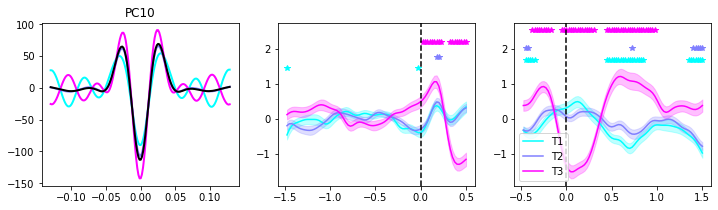

stat_fun(H1): min=-4.665864 max=5.278716
Running initial clustering …
Using 1056 thresholds from 0.00 to 5.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.343068 max=4.952084
Running initial clustering …
Using 991 thresholds from 0.00 to 4.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.322364 max=5.054036
Running initial clustering …
Using 1465 thresholds from 0.00 to 7.32 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.576775 max=2.653322
Running initial clustering …
Using 1316 thresholds from 0.00 to 6.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.662230 max=5.209684
Running initial clustering …
Using 1333 thresholds from 0.00 to 6.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

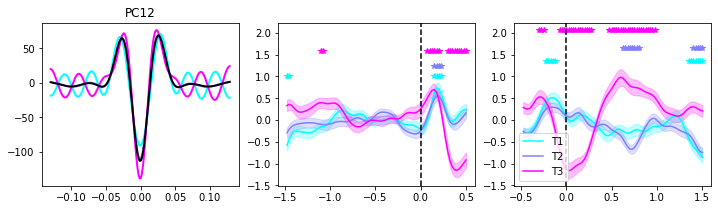

In [150]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: [] for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            stim_trials = np.unique(all_bursts['trial'][stim_b_idx])
            resp_trials = np.unique(all_bursts['trial'][resp_b_idx])

            stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            stim_unsmoothed_rate = (stim_unsmoothed_rate / bin_width) / len(stim_trials)
            resp_unsmoothed_rate = (resp_unsmoothed_rate / bin_width) / len(resp_trials)

            stim_smoothed_rate = gaussian_filter1d(stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_smoothed_rate = gaussian_filter1d(resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-.75) & (stim_time_bins < -0.1))[0]
            base_rate = np.mean(stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 stim_smoothed_rate = (stim_smoothed_rate - base_rate)/base_rate*100
#                 resp_smoothed_rate = (resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[q]['STIM'].append(stim_smoothed_rate)
#                 q_rates_smoothed[q]['RESP'].append(resp_smoothed_rate)
            stim_smoothed_rate = (stim_smoothed_rate - base_rate)[stim_plt_idx]
            resp_smoothed_rate = (resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM'].append(stim_smoothed_rate)
            q_rates_smoothed[q]['RESP'].append(resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
        
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    # RESP
    ax2 = plt.subplot(1,3,3)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax2.legend()
    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.361767 max=2.481406
Running initial clustering …
Using 497 thresholds from 0.00 to 2.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.266230 max=1.340965
Running initial clustering …
Using 654 thresholds from 0.00 to 3.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.186411 max=2.494746
Running initial clustering …
Using 1038 thresholds from 0.00 to 5.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.139364 max=5.637263
Running initial clustering …
Using 1128 thresholds from 0.00 to 5.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.110815 max=4.232116
Running initial clustering …
Using 847 thresholds from 0.00 to 4.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

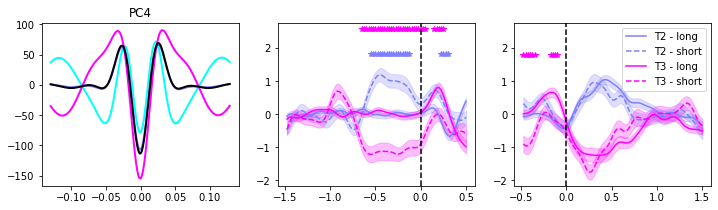

stat_fun(H1): min=-2.024780 max=2.241259
Running initial clustering …
Using 449 thresholds from 0.00 to 2.24 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.265511 max=1.706240
Running initial clustering …
Using 454 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.977329 max=2.260016
Running initial clustering …
Using 796 thresholds from 0.00 to 3.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.254254 max=3.588192
Running initial clustering …
Using 718 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.364773 max=4.201749
Running initial clustering …
Using 841 thresholds from 0.00 to 4.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

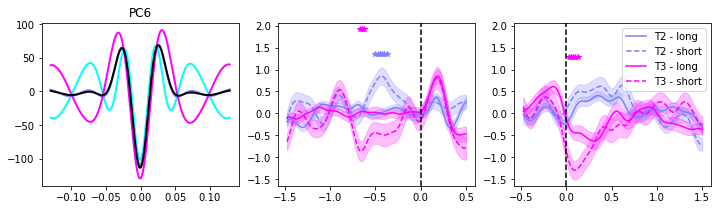

stat_fun(H1): min=-1.516237 max=4.941203
Running initial clustering …
Using 989 thresholds from 0.00 to 4.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.619664 max=3.420468
Running initial clustering …
Using 685 thresholds from 0.00 to 3.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.966594 max=1.168406
Running initial clustering …
Using 594 thresholds from 0.00 to 2.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.735318 max=1.273663
Running initial clustering …
Using 748 thresholds from 0.00 to 3.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.734064 max=2.055458
Running initial clustering …
Using 747 thresholds from 0.00 to 3.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

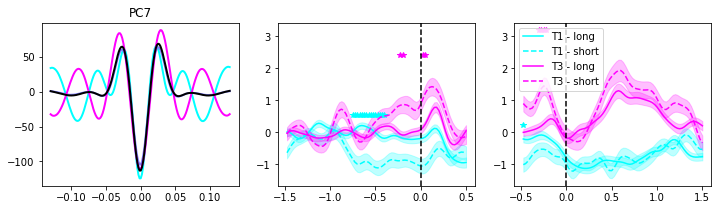

stat_fun(H1): min=-4.063610 max=1.183981
Running initial clustering …
Using 813 thresholds from 0.00 to 4.06 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.157180 max=3.189897
Running initial clustering …
Using 638 thresholds from 0.00 to 3.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.544959 max=2.789985
Running initial clustering …
Using 558 thresholds from 0.00 to 2.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.588990 max=7.893944
Running initial clustering …
Using 1579 thresholds from 0.00 to 7.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.839804 max=2.920840
Running initial clustering …
Using 1168 thresholds from 0.00 to 5.83 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

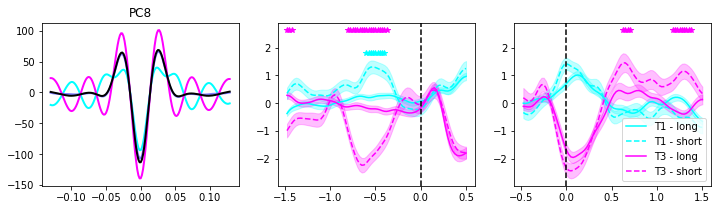

stat_fun(H1): min=-3.950237 max=2.070130
Running initial clustering …
Using 791 thresholds from 0.00 to 3.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.311446 max=1.277105
Running initial clustering …
Using 463 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.830919 max=2.082404
Running initial clustering …
Using 417 thresholds from 0.00 to 2.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.435197 max=7.502378
Running initial clustering …
Using 1501 thresholds from 0.00 to 7.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.942614 max=1.969862
Running initial clustering …
Using 589 thresholds from 0.00 to 2.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

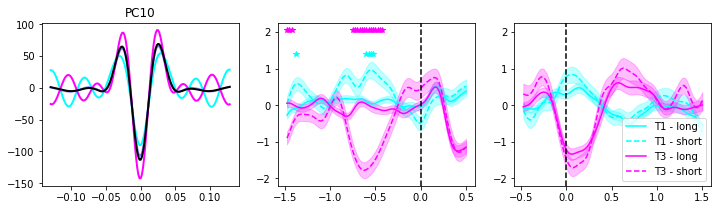

stat_fun(H1): min=-3.493652 max=1.313220
Running initial clustering …
Using 699 thresholds from 0.00 to 3.49 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.563938 max=1.275869
Running initial clustering …
Using 513 thresholds from 0.00 to 2.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.536040 max=2.064421
Running initial clustering …
Using 708 thresholds from 0.00 to 3.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.717579 max=5.363664
Running initial clustering …
Using 1073 thresholds from 0.00 to 5.36 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.010657 max=1.872784
Running initial clustering …
Using 403 thresholds from 0.00 to 2.01 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

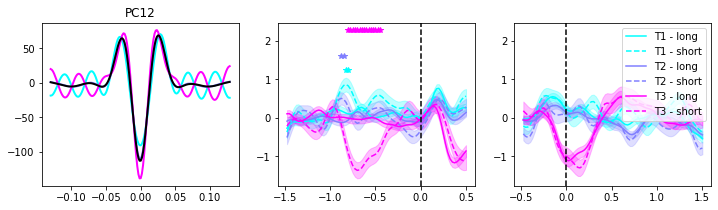

In [151]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins < -0.1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                 short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                 long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                 short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                 q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.339427 max=2.094769
Running initial clustering …
Using 468 thresholds from 0.00 to 2.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.315452 max=0.795736
Running initial clustering …
Using 464 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.898604 max=2.306347
Running initial clustering …
Using 1180 thresholds from 0.00 to 5.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.170801 max=4.359042
Running initial clustering …
Using 872 thresholds from 0.00 to 4.36 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.108485 max=2.988394
Running initial clustering …
Using 622 thresholds from 0.00 to 3.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

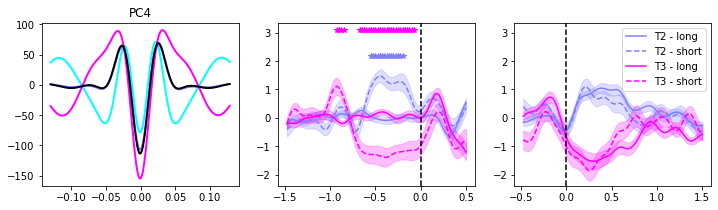

stat_fun(H1): min=-2.032785 max=2.472884
Running initial clustering …
Using 495 thresholds from 0.00 to 2.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.495440 max=2.017506
Running initial clustering …
Using 500 thresholds from 0.00 to 2.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.890253 max=2.444628
Running initial clustering …
Using 779 thresholds from 0.00 to 3.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.318777 max=3.501463
Running initial clustering …
Using 701 thresholds from 0.00 to 3.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.232730 max=2.627366
Running initial clustering …
Using 647 thresholds from 0.00 to 3.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

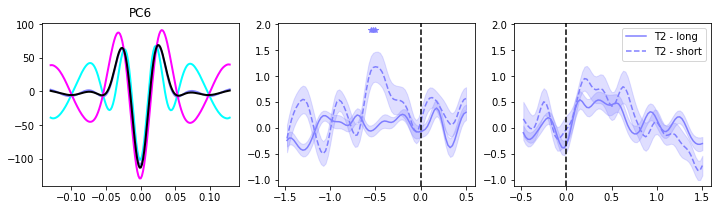

stat_fun(H1): min=-1.510807 max=3.636965
Running initial clustering …
Using 728 thresholds from 0.00 to 3.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.709925 max=3.461420
Running initial clustering …
Using 693 thresholds from 0.00 to 3.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.915673 max=0.945170
Running initial clustering …
Using 784 thresholds from 0.00 to 3.92 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.589909 max=1.366333
Running initial clustering …
Using 718 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.719315 max=1.800362
Running initial clustering …
Using 744 thresholds from 0.00 to 3.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

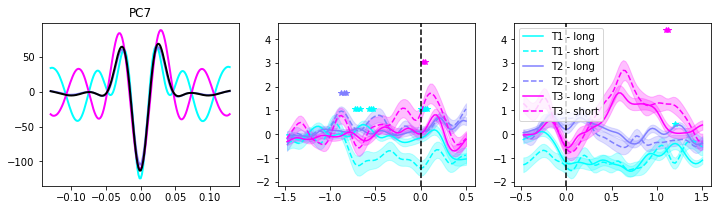

stat_fun(H1): min=-3.713043 max=1.123106
Running initial clustering …
Using 743 thresholds from 0.00 to 3.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.752652 max=3.332239
Running initial clustering …
Using 667 thresholds from 0.00 to 3.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.843768 max=1.543381
Running initial clustering …
Using 769 thresholds from 0.00 to 3.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.969803 max=7.861422
Running initial clustering …
Using 1573 thresholds from 0.00 to 7.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.497397 max=1.668716
Running initial clustering …
Using 900 thresholds from 0.00 to 4.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

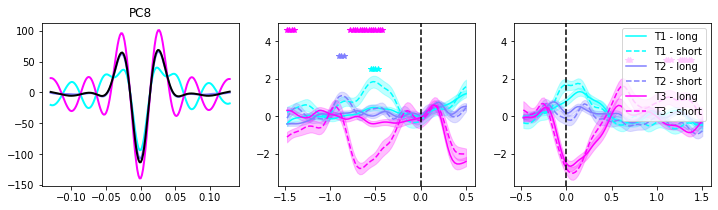

stat_fun(H1): min=-4.145565 max=2.045933
Running initial clustering …
Using 830 thresholds from 0.00 to 4.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.505031 max=1.531495
Running initial clustering …
Using 502 thresholds from 0.00 to 2.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.617093 max=1.746210
Running initial clustering …
Using 524 thresholds from 0.00 to 2.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.924055 max=6.930845
Running initial clustering …
Using 1387 thresholds from 0.00 to 6.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.514070 max=2.614711
Running initial clustering …
Using 523 thresholds from 0.00 to 2.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

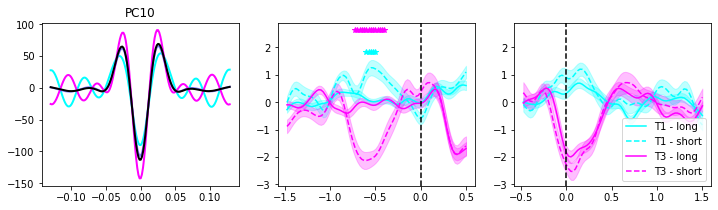

stat_fun(H1): min=-4.132572 max=1.328122
Running initial clustering …
Using 827 thresholds from 0.00 to 4.13 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.388758 max=1.520619
Running initial clustering …
Using 478 thresholds from 0.00 to 2.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.803531 max=2.055427
Running initial clustering …
Using 761 thresholds from 0.00 to 3.80 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.331143 max=5.775709
Running initial clustering …
Using 1156 thresholds from 0.00 to 5.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.748515 max=1.190186
Running initial clustering …
Using 550 thresholds from 0.00 to 2.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

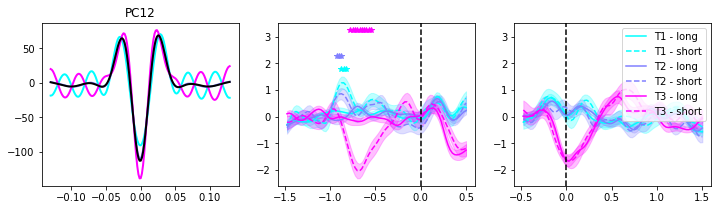

In [152]:
## TD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='TD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins < -0.1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#                 if base_rate>0:
#                     long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                     short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                     long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                     short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                     q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                     q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.345644 max=1.686461
Running initial clustering …
Using 470 thresholds from 0.00 to 2.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.038345 max=1.831825
Running initial clustering …
Using 608 thresholds from 0.00 to 3.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.898224 max=2.357850
Running initial clustering …
Using 580 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.051740 max=3.949377
Running initial clustering …
Using 790 thresholds from 0.00 to 3.95 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.847444 max=2.955987
Running initial clustering …
Using 592 thresholds from 0.00 to 2.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

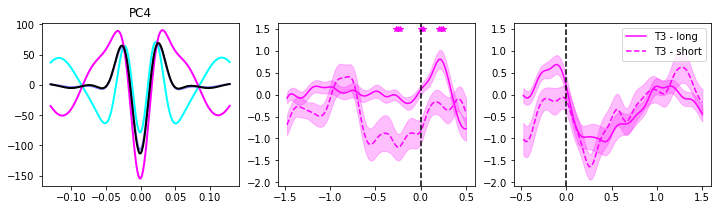

stat_fun(H1): min=-1.322872 max=2.084468
Running initial clustering …
Using 417 thresholds from 0.00 to 2.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.646329 max=0.708761
Running initial clustering …
Using 530 thresholds from 0.00 to 2.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.826247 max=1.267192
Running initial clustering …
Using 566 thresholds from 0.00 to 2.83 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.904517 max=3.500791
Running initial clustering …
Using 701 thresholds from 0.00 to 3.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.966227 max=3.255998
Running initial clustering …
Using 652 thresholds from 0.00 to 3.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

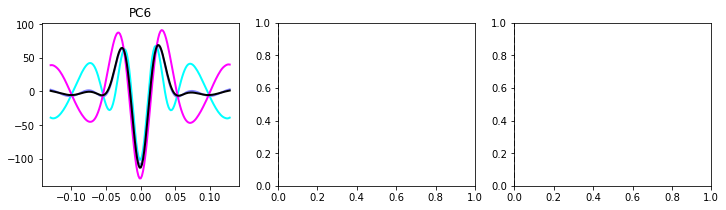

stat_fun(H1): min=-1.847512 max=3.782844
Running initial clustering …
Using 757 thresholds from 0.00 to 3.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.429279 max=1.814182
Running initial clustering …
Using 486 thresholds from 0.00 to 2.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.245809 max=1.287130
Running initial clustering …
Using 450 thresholds from 0.00 to 2.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.421835 max=1.001150
Running initial clustering …
Using 485 thresholds from 0.00 to 2.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.978715 max=1.148234
Running initial clustering …
Using 596 thresholds from 0.00 to 2.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

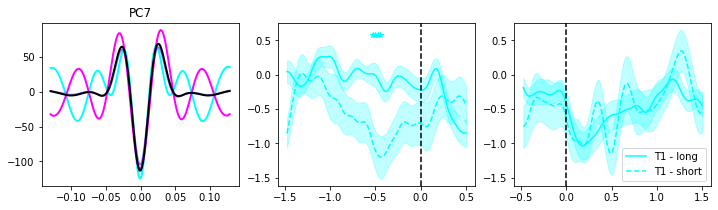

stat_fun(H1): min=-3.010899 max=1.215776
Running initial clustering …
Using 603 thresholds from 0.00 to 3.01 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.784329 max=1.988859
Running initial clustering …
Using 398 thresholds from 0.00 to 1.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.521243 max=3.402056
Running initial clustering …
Using 681 thresholds from 0.00 to 3.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.154842 max=4.873373
Running initial clustering …
Using 975 thresholds from 0.00 to 4.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.180187 max=2.974030
Running initial clustering …
Using 837 thresholds from 0.00 to 4.18 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

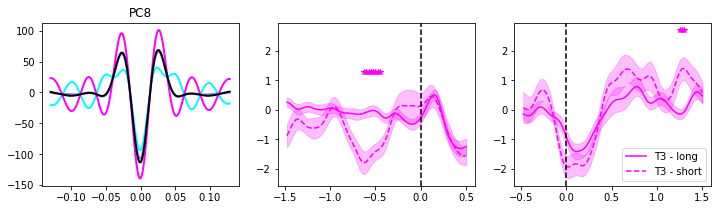

stat_fun(H1): min=-3.150442 max=1.528155
Running initial clustering …
Using 631 thresholds from 0.00 to 3.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.706295 max=2.031322
Running initial clustering …
Using 407 thresholds from 0.00 to 2.03 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.033977 max=1.653468
Running initial clustering …
Using 331 thresholds from 0.00 to 1.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.774728 max=4.889507
Running initial clustering …
Using 978 thresholds from 0.00 to 4.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.902839 max=1.337489
Running initial clustering …
Using 581 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

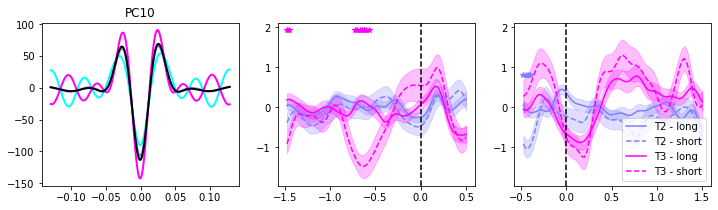

stat_fun(H1): min=-2.861782 max=1.115292
Running initial clustering …
Using 573 thresholds from 0.00 to 2.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.569431 max=1.398868
Running initial clustering …
Using 714 thresholds from 0.00 to 3.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.635301 max=2.474996
Running initial clustering …
Using 495 thresholds from 0.00 to 2.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.795485 max=2.819231
Running initial clustering …
Using 564 thresholds from 0.00 to 2.81 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.181803 max=2.810770
Running initial clustering …
Using 563 thresholds from 0.00 to 2.81 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

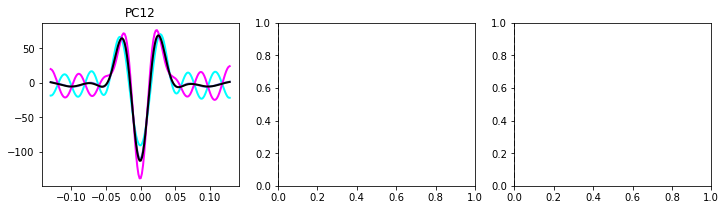

In [153]:
## ASD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='ASD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins < -0.1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#                 if base_rate>0:
#                     long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                     short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                     long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                     short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                     q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                     q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=0.000113 max=5.479487
Running initial clustering …
Using 1096 thresholds from 0.00 to 5.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000050 max=8.567291
Running initial clustering …
Using 1714 thresholds from 0.00 to 8.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000922 max=1.934791
Running initial clustering …
Using 387 thresholds from 0.00 to 1.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000577 max=4.989437
Running initial clustering …
Using 998 thresholds from 0.00 to 4.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000051 max=4.960440
Running initial clustering …
Using 993 thresholds from 0.00 to 4.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

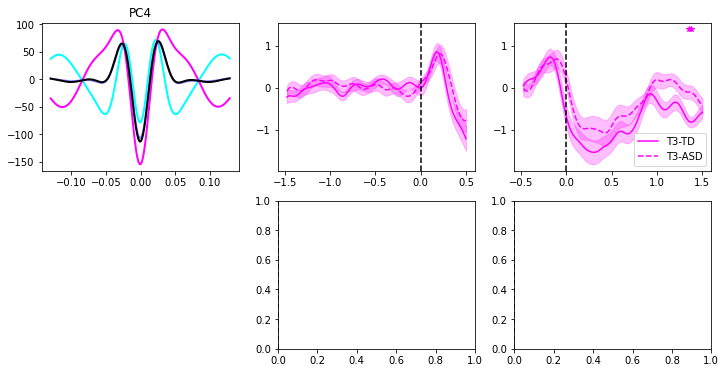

stat_fun(H1): min=0.000001 max=4.855359
Running initial clustering …
Using 972 thresholds from 0.00 to 4.86 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000001 max=8.141688
Running initial clustering …
Using 1629 thresholds from 0.00 to 8.14 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000062 max=5.622341
Running initial clustering …
Using 1125 thresholds from 0.00 to 5.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000008 max=2.641858
Running initial clustering …
Using 529 thresholds from 0.00 to 2.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000080 max=2.073096
Running initial clustering …
Using 415 thresholds from 0.00 to 2.07 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

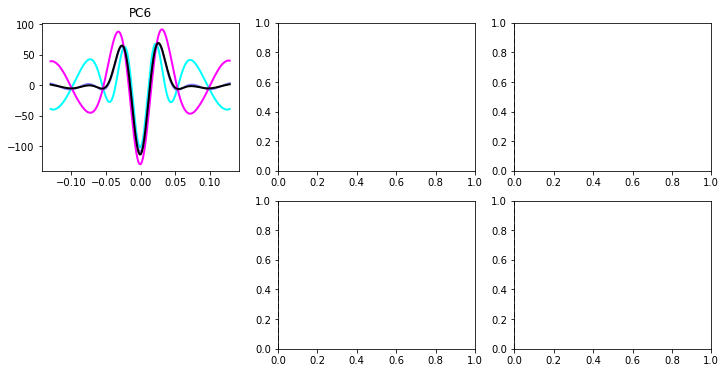

stat_fun(H1): min=0.000005 max=3.379825
Running initial clustering …
Using 676 thresholds from 0.00 to 3.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.009020 max=18.735313
Running initial clustering …
Using 3748 thresholds from 0.00 to 18.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000004 max=2.908290
Running initial clustering …
Using 582 thresholds from 0.00 to 2.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000012 max=2.042713
Running initial clustering …
Using 409 thresholds from 0.00 to 2.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002408 max=9.121286
Running initial clustering …
Using 1825 thresholds from 0.00 to 9.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

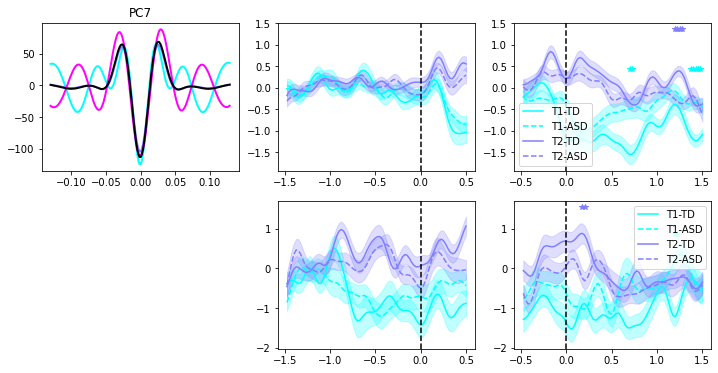

stat_fun(H1): min=0.000000 max=4.681860
Running initial clustering …
Using 937 thresholds from 0.00 to 4.68 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000008 max=6.128650
Running initial clustering …
Using 1226 thresholds from 0.00 to 6.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002379 max=8.685865
Running initial clustering …
Using 1738 thresholds from 0.00 to 8.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000013 max=6.399133
Running initial clustering …
Using 1280 thresholds from 0.00 to 6.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000056 max=4.913628
Running initial clustering …
Using 983 thresholds from 0.00 to 4.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

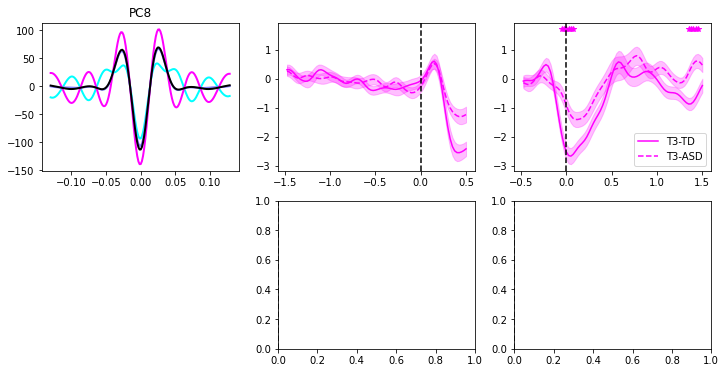

stat_fun(H1): min=0.000421 max=6.598112
Running initial clustering …
Using 1320 thresholds from 0.00 to 6.59 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000046 max=7.707641
Running initial clustering …
Using 1542 thresholds from 0.00 to 7.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000139 max=2.432580
Running initial clustering …
Using 487 thresholds from 0.00 to 2.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000188 max=8.739810
Running initial clustering …
Using 1748 thresholds from 0.00 to 8.73 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000022 max=12.982894
Running initial clustering …
Using 2597 thresholds from 0.00 to 12.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

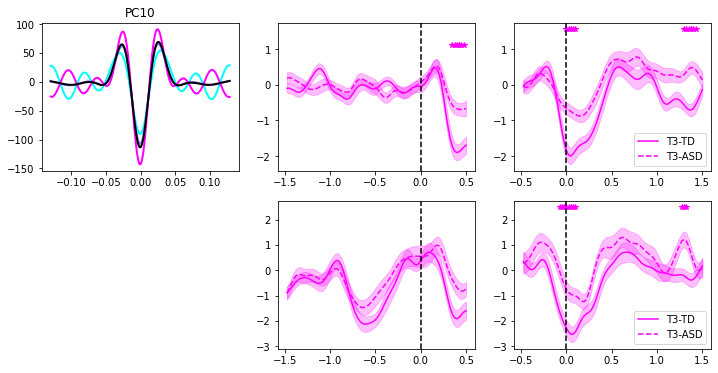

stat_fun(H1): min=0.000046 max=2.761350
Running initial clustering …
Using 553 thresholds from 0.00 to 2.76 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000696 max=3.852185
Running initial clustering …
Using 771 thresholds from 0.00 to 3.85 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000056 max=5.647965
Running initial clustering …
Using 1130 thresholds from 0.00 to 5.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000051 max=10.535127
Running initial clustering …
Using 2108 thresholds from 0.00 to 10.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000133 max=6.661219
Running initial clustering …
Using 1333 thresholds from 0.00 to 6.66 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

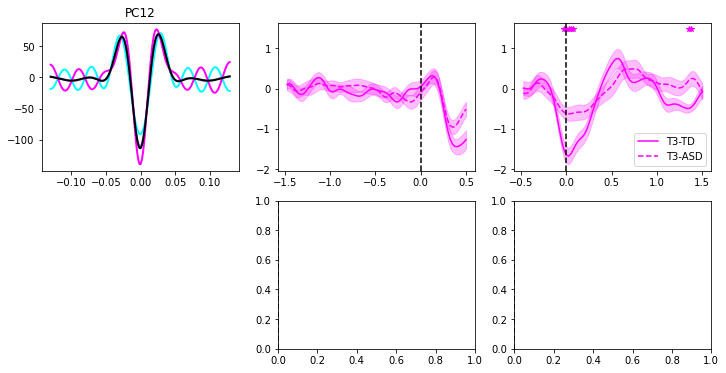

In [154]:
step = 100 / n_q

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        group: {
            q: {
                epoch_type: {
                    condition: [] for condition in condition_names
                } for epoch_type in epoch_types
            } for q in range(n_q)
        } for group in ['ASD','TD']
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins < -0.1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                 short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                 long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                 short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[subject_group][q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[subject_group][q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,6))

    ax=plt.subplot(2,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(2,3,2)
    # RESP
    ax2 = plt.subplot(2,3,3)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['LONG']), np.array(q_rates_smoothed['ASD'][q]['STIM']['LONG'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['LONG']), np.array(q_rates_smoothed['ASD'][q]['RESP']['LONG'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    
    ax1 = plt.subplot(2,3,5)
    # RESP
    ax2 = plt.subplot(2,3,6)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )

        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()